In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
g10, δ, Δ = sym.symbols("g_{10}, δ, Δ")

In [4]:
H1 = sym.Matrix([[0, g10, 0],
                 [g10, -Δ, 0],
                 [0, 0, δ]])
H1

Matrix([
[     0, g_{10}, 0],
[g_{10},     -Δ, 0],
[     0,      0, δ]])

In [5]:
H1.eigenvects()

[(δ,
  1,
  [Matrix([
   [0],
   [0],
   [1]])]),
 (-Δ/2 - sqrt(4*g_{10}**2 + Δ**2)/2,
  1,
  [Matrix([
   [Δ/g_{10} + (-Δ/2 - sqrt(4*g_{10}**2 + Δ**2)/2)/g_{10}],
   [                                                    1],
   [                                                    0]])]),
 (-Δ/2 + sqrt(4*g_{10}**2 + Δ**2)/2,
  1,
  [Matrix([
   [Δ/g_{10} + (-Δ/2 + sqrt(4*g_{10}**2 + Δ**2)/2)/g_{10}],
   [                                                    1],
   [                                                    0]])])]

In [6]:
g1 = 50
g2 = 10
ω = 5 + 1j*2
ω /= np.abs(ω)
d = 1

In [7]:
a = qu.destroy(2)
Ha = ω * a.dag() * a
Hb = d * a.dag() * a

In [8]:
Ha.eigenstates()

(array([0.        +0.j        , 0.92847669+0.37139068j]),
 array([Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]]                                                                ,
        Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]]                                                                ],
       dtype=object))

Kevin mentioned that it would be a good idea if we could demonstrate that the Green's function approach yields the bare cavity response in the limit of no atoms.  This should be something like a complex Lorentzian $\frac{1}{\omega-\omega_c}$.

In [9]:
# Define ωc
ωc = 5 + 1j*5

# Define detuning ω - ωc
δ = np.linspace(-20, 20, 100)
ωs = δ + 5

In [10]:
# Define Hamiltonian for cavity
a = qu.destroy(2)
Hc = ωc * a.dag() * a

# Get the eigenstates
Hc_eigs = Hc.eigenstates()

If there are no atoms and no driving term, then there's no perturbation of the cavity, so $V=0$.  Calculating the level shift function with $|\phi_b\rangle = |1\rangle$ therefore yields zero.  The transfer function is then just $G_{bb}(\omega) = \frac{1}{\omega-E_b}$ where $E_b$ is the eigenvalue of the eigenstate.

In [11]:
Hc_eigs[0][1]

np.complex128(5+5j)

In [12]:
# Calculate the transfer function
Gb = 1 / (ωs - Hc_eigs[0][1])

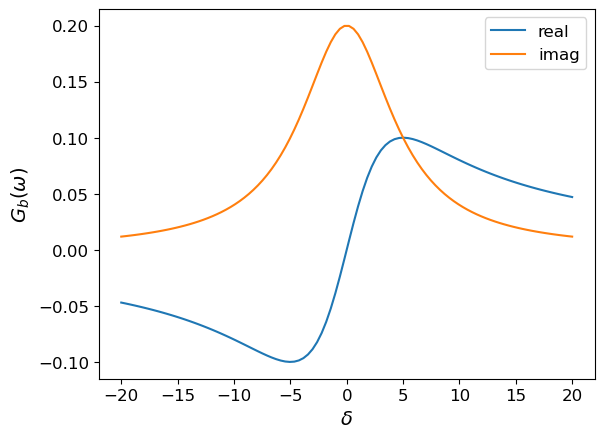

In [13]:
plt.plot(δ, Gb.real, label='real')
plt.plot(δ, Gb.imag, label='imag')
plt.xlabel("$\\delta$")
plt.ylabel("$G_b(\\omega)$")
plt.legend()

Text(0, 0.5, '$|G_b(\\omega)$|^2')

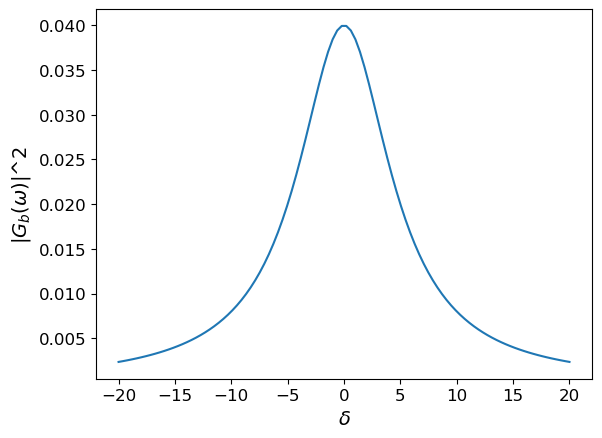

In [14]:
# Plot
plt.plot(δ, np.abs(Gb)**2)
plt.xlabel("$\\delta$")
plt.ylabel("$|G_b(\\omega)$|^2")

I think that this is different though.  If we used an eigenstate with $n$ photons, the eigenenergy would be $E_n=n\omega_c$, and we wouldn't get the same curve unless we accounted for this in defining the detuning.

Now let's try to calculate $G_{kl}(z) = \langle\phi_k|G(z)|\phi_l\rangle$ for the eigenstates of a system with a single atom.  This should allow us to effectively calculate the probability of ending up in $|\phi_k\rangle$ given we start in $|\phi_l\rangle$, which should be related to the transmission of the system.  This is effectively what we did when we were trying to use perturbation theory, and it seems that this is what they're doing in the Kurucz paper.  In their case, however, they only have one eigenstate corresponding to the cavity $|1, 0, \cdots, 0\rangle$.  Here, we have to consider ending up in $|1, 0\rangle$ or $|1, 1\rangle$.

For reference, we are using Eq. (A.25) in Ch. 3 of the Cohen-Tannoudji book and so $G_{kl}(z) = \frac{1}{z-E_k}\delta_{kl} + \frac{1}{z-E_k}V_{kl}\frac{1}{z-E_l} + \sum_i \frac{1}{z-E_k}V_{ki}\frac{1}{z-E_i}V_{il}\frac{1}{z-E_l} + \cdots$.  We will start by considering only up to the third term and note that we will probably have to show that this doesn't introduce too much error later.

In [15]:
def Gkl(z, Ek, ϕk, El, ϕl, H_eig, V):
    """
    Function for calculating the kl-th matrix element of G(z) using Eq. (A.25) of Ch. 3 of the C-T textbook
    :param z:     the complex argument
    :param ϕk:    eigenstate 1
    :param Ek:    eigenvalue of state 1
    :param ϕl:    eigenstate 2
    :param El:    eigenvalue of state 2
    :param H_eig: the other eigenstates of H0
    :param V:     the perturbation matrix
    :return:      array of the values of G_kl as z varies
    """
    # Calculate the first term
    first_term = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        first_term[i] = 1 / (z[i] - Ek) * ϕk.dag() * ϕl
    
    # Calculate the second term
    snd_term = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        snd_term[i] = 1 / (z[i] - Ek) * ϕk.dag() * V * ϕl * 1 / (z[i] - El)

    # Calculate the third term
    thrd_term = np.zeros(z.shape[0], dtype=complex)
    for j in range(z.shape[0]):
        thrd_term[j] = np.sum([1/(z[j]-Ek) * ϕk.dag() * V * H_eig[1][i] * 1/(z[j]-H_eig[0][i]) * H_eig[1][i].dag() * V * ϕl * 1/(z[j]-El)
                         for i in range(H_eig[0].shape[0])])

    frth_term = np.zeros(z.shape[0], dtype=complex)
    for j in range(z.shape[0]):
        frth_term[j] = np.sum([
            1/(z[j]-Ek)*ϕk.dag()*V*H_eig[1][i] * 1/(z[j]-H_eig[0][i])*H_eig[1][i].dag()*V*H_eig[1][k] * 1/(z[j]-H_eig[0][k])*H_eig[1][k].dag()*V*ϕl *1/(z[j]-El)
        for i in range(H_eig[0].shape[0]) for k in range(H_eig[0].shape[0])])

    fifth_term = np.zeros(z.shape[0], dtype=complex)
    for j in range(z.shape[0]):
        frth_term[j] = np.sum([(
            1/(z[j]-Ek)*ϕk.dag()*V*H_eig[1][i] * 
            1/(z[j]-H_eig[0][i])*H_eig[1][i].dag()*V*H_eig[1][k] * 
            1/(z[j]-H_eig[0][k])*H_eig[1][k].dag()*V*H_eig[1][p] *
            1/(z[j]-H_eig[0][p])*H_eig[1][p].dag()*V*ϕl *
            1/(z[j]-El)
        )
        for i in range(H_eig[0].shape[0]) for k in range(H_eig[0].shape[0]) for p in range(H_eig[0].shape[0])])

        
    return first_term + snd_term + thrd_term + frth_term + fifth_term

In [16]:
def exact_resolvent(z, H):
    return (z - H).inv()

In [17]:
# Define the parameters for the Hamiltonian
g10 = 5
g21 = 10
Δ1 = 0.1
ω21 = 5
ωc = 5
κ = 1
γ21 = 1
γ10 = 0.05

In [18]:
# Define the operators
a = qu.destroy(2)

σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

Ic = qu.qeye(2)
Ia = qu.qeye(3)

In [19]:
# Define the Hamiltonian parts
Hc = (ωc - 1j*κ) * a.dag() * a
Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω21 - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), Ha)
H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0. +0.j    5. +0.j    0. +0.j    0. +0.j    0. +0.j    0. +0.j  ]
 [ 5. +0.j   -0.1-0.05j  0. +0.j    0. +0.j    0. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    4.9-1.j    0. +0.j    0. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j    5. -1.j    5. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j    5. +0.j    4.9-1.05j  0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j    0. +0.j    0. +0.j    9.9-2.j  ]]

In [20]:
# Define the perturbation
V = g21 * (qu.tensor(a, σ21.dag()) + qu.tensor(a.dag(), σ21))
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]

In [21]:
# Get the eigenstates of H0
H0_eigs = H0.eigenstates()

Now because $H_0 = H_c \otimes I_a + I_c \otimes H_a$, we know that its eigenstates are tensor product combinations of the eigenstates of $H_c$ and $H_a$.  The eigenstates of $H_c$ are simple because its diagonal in the cavity basis and are $|0\rangle$ and $|1\rangle$.  The eigenstates of $H_a$ are a bit more involved, but we can get them easily.

In [22]:
# Get the eigenstates of Hc and Ha
Hc_eigs = Hc.eigenstates()
Ha_eigs = Ha.eigenstates()
Ha_eigs

(array([-5.0501875-0.02524999j,  4.9      -1.j        ,
         4.9501875-0.02475001j]),
 array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.7035537 +0.00351764j]
         [ 0.71063339+0.j        ]
         [ 0.        +0.j        ]]                                           ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]]                                                                ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.71063339+0.j        ]
         [ 0.7035537 -0.00351764j]
         [-0.        +0.j        ]]                                           ],
       dtype=object))

The atomic excitation states are such that $|0\rangle = (1, 0, 0), |1\rangle = (0, 1, 0)$, and $|2\rangle = (0, 0, 1)$ in the computational basis.  That means that looking at the above, we can see that we get 2 eigenstates that are linear combinations of $|0\rangle$ and $|1\rangle$ and one that is just $|2\rangle$.  We're interested in the probability of ending up with the photon in the cavity and the atom in either $|0\rangle$ or $|1\rangle$ from what I can determine.  If we define $|\phi_l\rangle = |n, \epsilon_m\rangle$, where $m=(0,1,2)$ denotes the index in the array of the eigenstates of $H_a$, we want $n=1, m=0,2$.

In [23]:
# Define the eigenstates we want to look at
ϕ10 = qu.tensor(Hc_eigs[1][1], Ha_eigs[1][0])
E10 = Hc_eigs[0][1] + Ha_eigs[0][0]
ϕ12 = qu.tensor(Hc_eigs[1][1], Ha_eigs[1][2])
E12 = Hc_eigs[0][1] + Ha_eigs[0][2]

In [24]:
# Define our complex argument
ω = np.linspace(-50, 50, 500)

In [25]:
# Calculate the transfer function
G1010 = Gkl(ω+ωc, E10, ϕ10, E10, ϕ10, H0_eigs, V)
G1012 = Gkl(ω+ωc, E10, ϕ10, E12, ϕ12, H0_eigs, V)
G1210 = Gkl(ω+ωc, E12, ϕ12, E10, ϕ10, H0_eigs, V)
G1212 = Gkl(ω+ωc, E12, ϕ12, E12, ϕ12, H0_eigs, V)

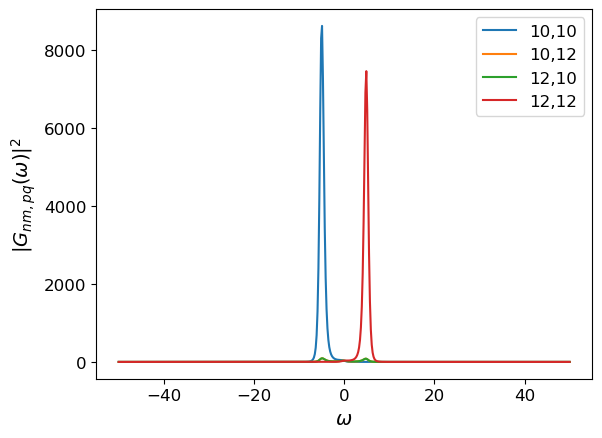

In [26]:
plt.plot(ω, np.abs(G1010) ** 2, label="10,10")
plt.plot(ω, np.abs(G1012) ** 2, label="10,12")
plt.plot(ω, np.abs(G1210) ** 2, label="12,10")
plt.plot(ω, np.abs(G1212) ** 2, label="12,12")
plt.xlabel("$\\omega$")
plt.ylabel("$|G_{nm,pq}(\\omega)|^2$")
plt.legend()

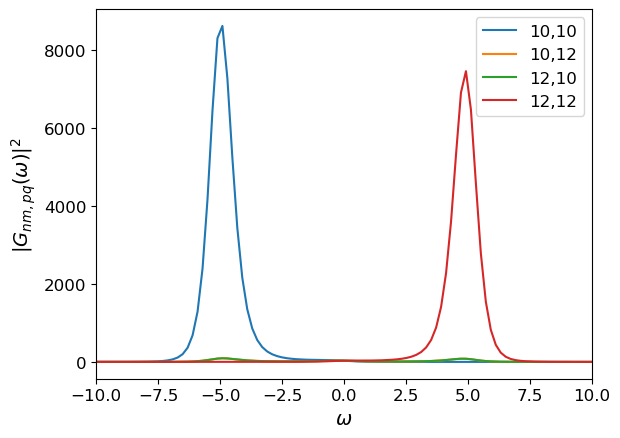

In [27]:
plt.plot(ω, np.abs(G1010) ** 2, label="10,10")
plt.plot(ω, np.abs(G1012) ** 2, label="10,12")
plt.plot(ω, np.abs(G1210) ** 2, label="12,10")
plt.plot(ω, np.abs(G1212) ** 2, label="12,12")
plt.xlabel("$\\omega$")
plt.ylabel("$|G_{nm,pq}(\\omega)|^2$")
plt.xlim([-10,10])
plt.legend()

In [28]:
# Calculate the exact results
exact_1010 = np.array([ϕ10.dag() * exact_resolvent(_ + ωc, H0 + V) * ϕ10 for _ in ω])
exact_1012 = np.array([ϕ10.dag() * exact_resolvent(_ + ωc, H0 + V) * ϕ12 for _ in ω])
exact_1210 = np.array([ϕ12.dag() * exact_resolvent(_ + ωc, H0 + V) * ϕ10 for _ in ω])
exact_1212 = np.array([ϕ12.dag() * exact_resolvent(_ + ωc, H0 + V) * ϕ12 for _ in ω])

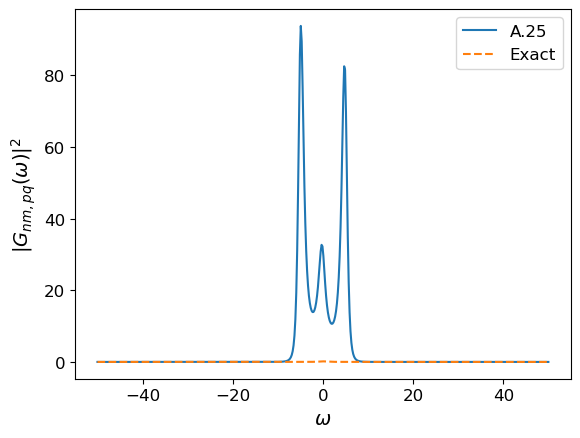

In [29]:
plt.plot(ω, np.abs(G1210) ** 2, label="A.25")
plt.plot(ω, np.abs(exact_1012) ** 2, '--', label='Exact')
plt.xlabel("$\\omega$")
plt.ylabel("$|G_{nm,pq}(\\omega)|^2$")

plt.legend()

So these results looks pretty different from those that we obtained using perturbation theory for a single atom.  Thinking about it some more, I think that this is because we applied the perturbation to a different system than we're considering here.  To be clear, the results using the Green's function approach are obtained using $H = H_0 + V$ with $H_0 = \omega_c a^\dag a - \Delta_1\sigma_{10}^\dag\sigma_{10} + (\omega_{21}-\Delta_1)\sigma_{21}^\dag\sigma_{21} + g_{10}(\sigma_{10}^\dag + \sigma_{10})$ and $V=g_{21}(a\sigma_{21}^\dag + a^\dag \sigma_{21})$.  The old perturbation theory results use $H=H_p + H_u + V_p$ with $H_p = -i\kappa|1,0\rangle\langle1,0| - (\Delta_1+i\kappa+i\gamma_{10})|1,1\rangle\langle1,1| - (\Delta_1+\delta+i\gamma_{21})|0,2\rangle\langle0,2| + g_{10}(|1,1\rangle\langle1,0| + |1,0\rangle\langle1,1|) + g_{21}(|0,2\rangle\langle1,1| + |1,1\rangle\langle0,2|)$, $H_u = \delta_L|0,0\rangle\langle0,0| + (\delta_L-\Delta_1-i\gamma_{10})|0,1\rangle\langle0,1| + g_{10}(|0,1\rangle\langle0,0| + |0,0\rangle\langle0,1|)$, and $V_p = |1,1\rangle\langle0,1| + |1,0\rangle\langle0,0| + h.c.$.

The difference between the systems is the perturbation.  In the Green's function approach we're using here, we let the perturbation refer to the interaction between the cavity and the atom.  In the perturbation theory results, we let it be the creation or annihilation of a photon in the cavity mode.  In fact, if we set $\delta_L=0$ and incorporate the imaginary terms into the frequency terms, we have $H_p + H_u = H_0 + V$.  So it seems that we can't really compare these results to the perturbation theory results directly.  But it should be possible to apply either method to either system, and then we would expect to get the same results.

Another difference is in how the results were obtained, which is worth discussing as well.  In the Green's function approach, we obtain $G(z) = \frac{1}{z-H}$ where $z$ is a complex variable that basically picks out the eigenvalues of $H$.  Then we can calculate the transition amplitude between two states $|\psi_i\rangle$ and $|psi_f\rangle$ by evaluating $\langle\psi_f|G(z)|\psi_i\rangle$.  This allows us to calculate the transmission spectrum of the system as a function of $z$.  In the perturbation theory, there really isn't a clear analog for $z$.  We obtain the transmission spectrum as a function of the detuning by recconstructing the Hamiltonian at every value of the detuning and recalculating the probability amplitude of the new perturbed eigenstate.  This means that the perturbation theory spectrum is obtained as a function of an experimental parameter, while the Green's function method is not.  I think that we should be able to do basically the same thing, however, by setting $z = z_0$ and recalculating $G(z_0)$ as we adjust the detuning.  At least, that's what we'll try first.

In [30]:
def pert_theory(ϕn, En, V, H0_eigs, left_H0_eigs):
    """
    Function for evaluating standard perturbation theory on state |ϕn> using H0 and V
    :param ϕn:       the eigenstate to be perturbed
    :param En:       the energy of the eigenstate to be perturbed
    :param V:        the perturbation matrix
    :param H0_eigs:  the other eigenvalues and eigenstates of H0
    """
    # First we need to mask ϕn
    temp = np.array([ϕn])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the mask array
    mask = np.ones(H0_eigs[1].shape[0], dtype=bool)

    # Eliminate the index to exclude in the mask
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues
    mask_vals = H0_eigs[0][mask]
    mask_states = H0_eigs[1][mask]
    mask_left_states = left_H0_eigs[1][mask]

    # Get the perturbed eigenstate
    ϕn_λ = ϕn - np.sum([mask_left_states[i].dag() * V * ϕn / (mask_vals[i] - En) * mask_states[i] for i in range(mask_vals.shape[0])])

    return ϕn_λ

In [31]:
# Calculate the perturbed eigenstates as a function of ω
pert_1012 = np.zeros(ω.shape[0], dtype=complex)
for i in range(ω.shape[0]):
    temp_Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω[i]+ωc - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
    temp_H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), temp_Ha)
    temp_H0_eigs = temp_H0.eigenstates()
    temp_left_H0_eigs = temp_H0.dag().eigenstates()
    temp_pert_eig = pert_theory(ϕ12, E12, V, temp_H0_eigs, temp_left_H0_eigs)
    pert_1012[i] = ϕ10.dag() * temp_pert_eig

In [32]:
gf_1012 = np.zeros(ω.shape[0], dtype=complex)
for i in range(ω.shape[0]):
    temp_Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω[i]+ωc - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
    temp_H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), temp_Ha)
    temp_exact_gf = exact_resolvent(0, temp_H0 + V)
    gf_1012[i] = qu.tensor(qu.basis(2,1), qu.basis(3, 1)).dag() * temp_exact_gf * qu.tensor(qu.basis(2,1), qu.basis(3,0))

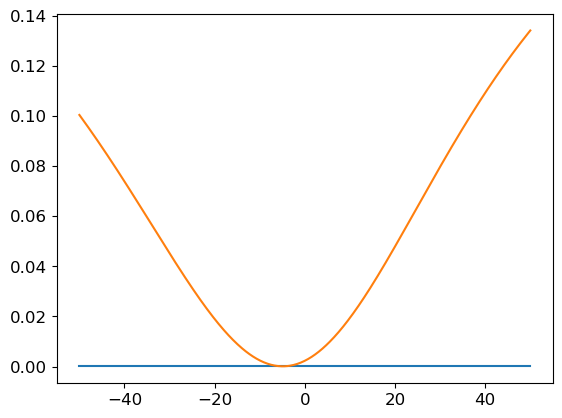

In [33]:
plt.plot(ω, np.abs(pert_1012) ** 2, label='Pert')
plt.plot(ω, np.abs(gf_1012) ** 2, label='GF')

In [34]:
# Calculate perturbed eigenstates at every detuning value
pert_eigs = np.zeros((ω.shape[0], H0_eigs[0].shape[0]), dtype=object)
left_pert_eigs = np.zeros((ω.shape[0], H0_eigs[0].shape[0]), dtype=object)
eig_vals = np.zeros((ω.shape[0], H0_eigs[0].shape[0]), dtype=complex)
for i in range(ω.shape[0]):
    temp_Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω[i]+ωc - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
    temp_H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), temp_Ha)
    temp_H0_eigs = temp_H0.eigenstates()
    temp_left_H0_eigs = temp_H0.dag().eigenstates()
    for j in range(H0_eigs[0].shape[0]):
        eig_vals[i][j] = temp_H0_eigs[0][j]
        temp = pert_theory(temp_H0_eigs[1][j], temp_H0_eigs[0][j], V, temp_H0_eigs, temp_left_H0_eigs)
        left_temp = pert_theory(temp_left_H0_eigs[1][j], temp_H0_eigs[0][j], V, temp_left_H0_eigs, temp_H0_eigs)
        pert_eigs[i][j] = temp / np.sqrt(left_temp.dag() * temp)
        left_pert_eigs[i][j] = left_temp / np.sqrt(left_temp.dag() * temp)

In [35]:
pert_Ts = np.zeros((ω.shape[0]))
for i in range(ω.shape[0]):
    temp = 0
    for j in range(H0_eigs[0].shape[0]):
        temp += np.abs(qu.tensor(qu.basis(2,1), qu.basis(3,1)).dag() * pert_eigs[i][j]) ** 2
    pert_Ts[i] = temp

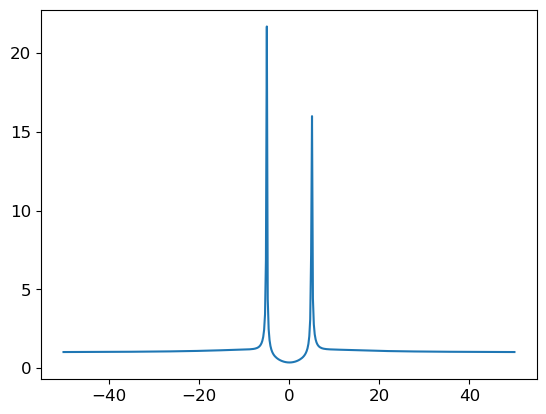

In [36]:
plt.plot(ω, pert_Ts)

So this doesn't really seem to be working as expected.  Maybe we really do need to have the perturbation be the removal/addition of a photon from the cavity mode in order to be able to interpret the overlap of the eigenstates as being proportional to the transmission spectrum?  It might be easier to set that up in the Green's function approach.

After thinking about this a bit more, it is probably worth noting that we can actually write $G(z) = \frac{1}{z-H} = \sum_k\frac{1}{z-E_k^\lambda}|\phi_k^\lambda\rangle\langle\phi_k^\lambda|$, where $|\phi_k^\lambda\rangle$ is the $k^{th}$ eigenstate of $H$ with eigenvalue $E_k^\lambda$.  We use the $\lambda$ subscripts here because they should be equivalent to the eigenstates and eigenvalues obtained using perturbation theory.  If we then multiply on the left by a particular eigenstate, we obtain $G(z)|\phi_n^\lambda\rangle = \frac{1}{z-E_n^\lambda}|\phi_n^\lambda\rangle$.  This tells us how the results of perturbation theory are connected to the transfer function obtained using our Green's function approach.  We can verify this for the system above.

In [37]:
Gs = np.zeros(ω.shape[0], dtype=object)
for i in range(ω.shape[0]):
    temp_Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω[i]+ωc - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
    temp_H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), temp_Ha)
    Gs[i] = exact_resolvent(0, temp_H0 + V)

In [38]:
Gs[0] * pert_eigs[0][0]

Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j]
 [ 0.02134752-8.22615647e-05j]
 [-0.00179964-2.17002303e-03j]
 [-0.00171802+1.82826557e-03j]
 [ 0.        +0.00000000e+00j]]

In [39]:
-1/eig_vals[0][0] * pert_eigs[0][0]

Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j]
 [ 0.02171928-4.95885087e-04j]
 [ 0.00043784-1.17225966e-05j]
 [-0.00438716+1.17460418e-04j]
 [ 0.        +0.00000000e+00j]]

In [40]:
errs = np.zeros((ω.shape[0], H0_eigs[0].shape[0]))
for i in range(ω.shape[0]):
    for j in range(H0_eigs[0].shape[0]):
        gf = Gs[i] * pert_eigs[i][j]
        scaled_pert = -1/eig_vals[i][j] * pert_eigs[i][j]
        errs[i][j] = (gf - scaled_pert).norm() / scaled_pert.norm()

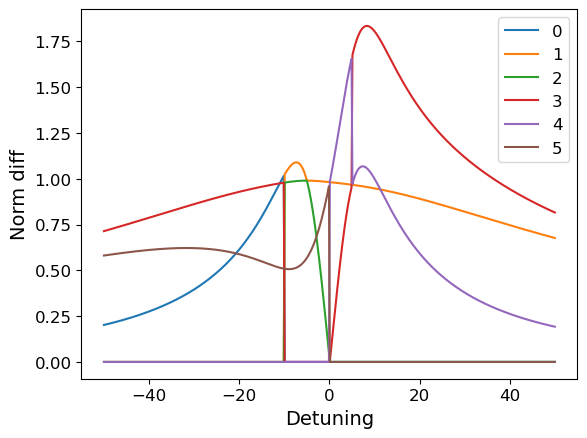

In [41]:
for i in range(H0_eigs[0].shape[0]):
    plt.plot(ω, errs.T[i], label=str(i))
plt.xlabel("Detuning")
plt.ylabel("Norm diff")
plt.legend()

So this seems pretty good for the most part.  We do have a spike in the second eigenstate at around $\omega = -4.9$, but I think that this is because the corresponding eigenvalue is pretty small compared to its neighbors, i.e. $\approx \mathcal{O}(10^{-3})$ instead of $\mathcal{O}(10^{-1})$.

Now we want to move onto testing a cavity system with a single atom and a coherent drive like we did for perturbation theory before.  It is probably also a good idea to do this with the system discussed in the Ningyuang paper where the cavity is coupled to the bottom transition instead of the top.  This is a simpler system because we don't have to worry about which eigenstates we're perturbing or which states we're considering to be the 'cavity' states for calculating the transmission spectrum.  We also have ready results that we can verify our calculations with, which is helpful.

We'll define $H_p$ and $H_u$ by multiplying the full Hamiltonian on the left and right by the basis states rather than operators because we have found it to be more convenient.  The states that are used to construct to $H_u$ are $\{|0,0\rangle\}$, while the states used to construct $H_p$ are $\{|1,0\rangle, |0,1\rangle, |0,2\rangle\}$.

In [42]:
# Define the basis vectors
cav_bas = [qu.basis(2,i) for i in range(2)]
atom_bas = [qu.basis(3,i) for i in range(3)]

In [43]:
# Redefine the full Hamiltonian.  Note that we have assumed that δc = Δ1 = 0
H = -1j*κ * qu.tensor(a.dag() * a, Ia) -1j*γ10 * qu.tensor(Ic, σ10.dag() * σ10) - 1j*γ21 * qu.tensor(Ic, σ21.dag() * σ21)
H += g21 * (qu.tensor(Ic, σ21.dag()) + qu.tensor(Ic, σ21)) + g10 * (qu.tensor(a, σ10.dag()) + qu.tensor(a.dag(), σ10))

# Get the eigenstates of H
H_eigs = H.eigenstates()

# Also get the left eigenstates of H
left_H_eigs = H.dag().eigenstates()

# Print H
H

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.-0.05j 10.+0.j    5.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j   10.+0.j    0.-1.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    5.+0.j    0.+0.j    0.-1.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.-1.05j 10.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j   10.+0.j    0.-2.j  ]]

In [44]:
# Create Hu
Hu = qu.tensor(cav_bas[0], atom_bas[0]).dag() * H * qu.tensor(cav_bas[0], atom_bas[0])
Hu

0j

In [45]:
# Create Hp
Hp_bas = [qu.tensor(cav_bas[0], atom_bas[i]) for i in range(1,3)]
Hp_bas.append(qu.tensor(cav_bas[1], atom_bas[0]))

Hp_mat = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_mat[i][j] = Hp_bas[i].dag() * H * Hp_bas[j]

# Now turn this into a Qobj
Hp = qu.Qobj(Hp_mat)
Hp

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.-0.05j 10.+0.j    5.+0.j  ]
 [10.+0.j    0.-1.j    0.+0.j  ]
 [ 5.+0.j    0.+0.j    0.-1.j  ]]

In [46]:
# Create the perturbation V
V = qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()
V += qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[1], atom_bas[0]).dag()
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

In [47]:
# Now we can create the total Hamiltonian
λ = 1e-3
Ht = H + λ * V
Ht

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00-0.05j 1.e+01+0.j   5.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   1.e+01+0.j   0.e+00-1.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [1.e-03+0.j   5.e+00+0.j   0.e+00+0.j   0.e+00-1.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00-1.05j
  1.e+01+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e+01+0.j
  0.e+00-2.j  ]]

In [48]:
# Define the detuning
δL = np.linspace(-50, 50, 500)

In [49]:
# From our setup, we know that the eigenvalues aren't perturbed, so we can use matrix inversion to obtain the perturbed eigenstates
# Create array for storing perturbed eigenstates
ψs = np.zeros(δL.shape[0], dtype=object)
for i in range(δL.shape[0]):
    ψs[i] = qu.tensor(cav_bas[0], atom_bas[0]) + (δL[i] - H).inv() * λ * V * qu.tensor(cav_bas[0], atom_bas[0])

In [50]:
# Now we want to calculate the resolvent as a function of δL
Gs = np.zeros(δL.shape[0], dtype=object)
for i in range(δL.shape[0]):
    temp = Ht + δL[i] * qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()
    Gs[i] = exact_resolvent(0, temp)

In [51]:
# Now we should be able to check the error between the two
errs = np.zeros(δL.shape[0])
for i in range(δL.shape[0]):
    gf = Gs[i] * ψs[i]
    scaled_pert = -1/δL[i] * ψs[i]
    errs[i] = (gf - scaled_pert).norm() / scaled_pert.norm()

Text(0, 0.5, 'Norm Diff.')

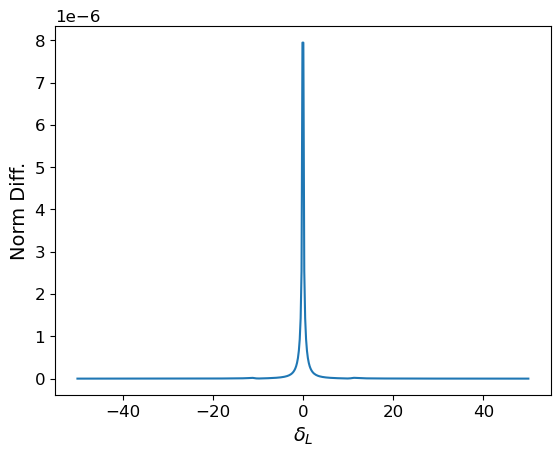

In [52]:
plt.plot(δL, errs)
plt.xlabel("$\\delta_L$")
plt.ylabel("Norm Diff.")

In [53]:
# Now let's plot the transmission spectrum
pert_trans = np.array([qu.tensor(cav_bas[1], atom_bas[0]).dag() * ψs[i] for i in range(δL.shape[0])])
gf_trans = np.array([qu.tensor(cav_bas[1], atom_bas[0]).dag() * -δL[i] * Gs[i] * ψs[i] for i in range(δL.shape[0])])

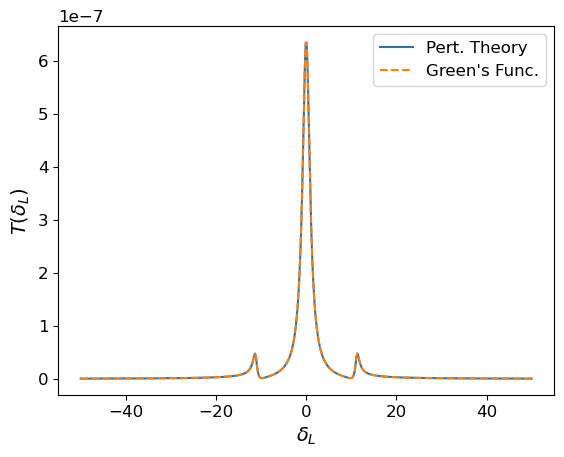

In [54]:
plt.plot(δL, np.abs(pert_trans) ** 2, label='Pert. Theory')
plt.plot(δL, np.abs(gf_trans) ** 2, '--', label="Green's Func.")
plt.xlabel("$\\delta_L$")
plt.ylabel("$T(\\delta_L)$")
plt.legend()
plt.savefig("pert_theory_greens_func_comp.png", format='png', dpi=300)

Thinking about it some more, this comparison to the perturbation theory results is a good check, but it's not really that useful because it requires having the perturbation theory results.  If we had those, we could just use the perturbation theory method.  Let's try and evaluate the scalar products of the transfer function using the eigenstates of the unperturbed Hamiltonian and see what we get as we shift the detuning.  Note that here, we're incorporating the coherent derive terms into $H_0$ because they only interact with the cavity and therefore don't make it any more difficult to calculate the eigenstates of $H_0$.  We'll also start by using the exact transfer function.  We'll use Eq. A.25 from Ch. 3 of CT later and compare those results to the exact ones.

In [55]:
# Redefine the coherent drive
Vd = qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()
Vd += qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[1], atom_bas[0]).dag()
#Vd = qu.tensor(a.dag(), Ia) + qu.tensor(a, Ia)
Vd

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

In [56]:
# Redefine the Hamiltonian for convenience
H0 = -1j*κ * qu.tensor(a.dag() * a, Ia) -1j*γ10 * qu.tensor(Ic, σ10.dag() * σ10) - 1j*γ21 * qu.tensor(Ic, σ21.dag() * σ21)
H0 += g21 * (qu.tensor(Ic, σ21.dag()) + qu.tensor(Ic, σ21))# + Vd
H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.-0.05j 10.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j   10.+0.j    0.-1.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.-1.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.-1.05j 10.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j   10.+0.j    0.-2.j  ]]

In [57]:
H0_eigs = H0.eigenstates()

In [58]:
# Define the interaction V
V = g10 * (qu.tensor(a, σ10.dag()) + qu.tensor(a.dag(), σ10))
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 5. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 5. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

In [59]:
# Now we want to calculate the resolvent as a function of δL
Gs = np.zeros(δL.shape[0], dtype=object)
scal_prods_0 = np.zeros((δL.shape[0], H0_eigs[0].shape[0]), dtype=complex)
test = np.zeros(δL.shape[0], dtype=complex)
for i in range(δL.shape[0]):
    # Update Hamiltonian
    temp = H0 #+ δL[i] * qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()

    # Get eigenstates
    temp_eigs = temp.eigenstates()
    temp_left_eigs = temp.dag().eigenstates()
    
    Gs[i] = exact_resolvent(δL[i], temp + Vd)
    for j in range(H0_eigs[0].shape[0]):
        scal_prods_0[i][j] = temp_left_eigs[1][0].dag() * Gs[i] * temp_eigs[1][j]

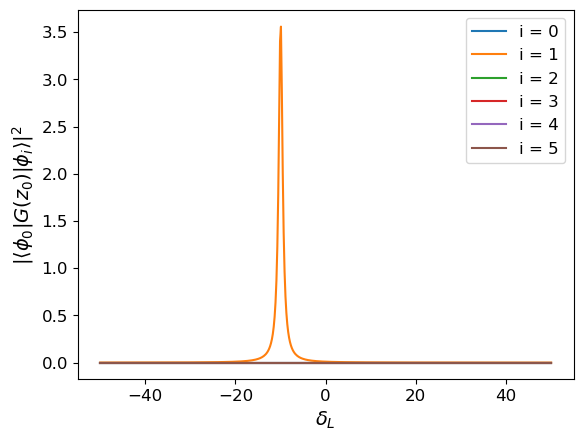

In [60]:
for i in range(H0_eigs[0].shape[0]):
    plt.plot(δL, np.abs(scal_prods_0.T[i]) ** 2, label="i = " + str(i))
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle\\phi_0|G(z_0)|\\phi_i\\rangle|^2$")
plt.legend()

So using the unperturbed eigenstates doesn't seem to work too well.  What if we use the normal cavity-atomic excitation basis states that we're interested in?  Really, we want to know what the overlap is between $|0,0\rangle$ and $|1,0\rangle$.  At least, I think that that's what we're interested in.

In [61]:
scal_prods = np.zeros(δL.shape[0], dtype=complex)
scal_prods_2 = np.zeros(δL.shape[0], dtype=complex)
scal_prods_3 = np.zeros(δL.shape[0], dtype=complex)
Gs = np.zeros(δL.shape[0], dtype=object)
for i in range(δL.shape[0]):
    temp = H0 #+ δL[i] * qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()
    
    # Get eigenstates
    temp_eigs = temp.eigenstates()
    temp_left_eigs = temp.dag().eigenstates()

    # Get the resolvent
    Gs[i] = exact_resolvent(δL[i], temp + V + λ * Vd)

    # Calculate the overlap
    scal_prods[i] = qu.tensor(cav_bas[1], atom_bas[0]).dag() * Gs[i] * qu.tensor(cav_bas[0], atom_bas[0])
    scal_prods_2[i] = qu.tensor(cav_bas[1], atom_bas[0]).dag() * Gs[i] * qu.tensor(cav_bas[0], atom_bas[1])
    scal_prods_3[i] = qu.tensor(cav_bas[1], atom_bas[0]).dag() * Gs[i] * qu.tensor(cav_bas[1], atom_bas[0])

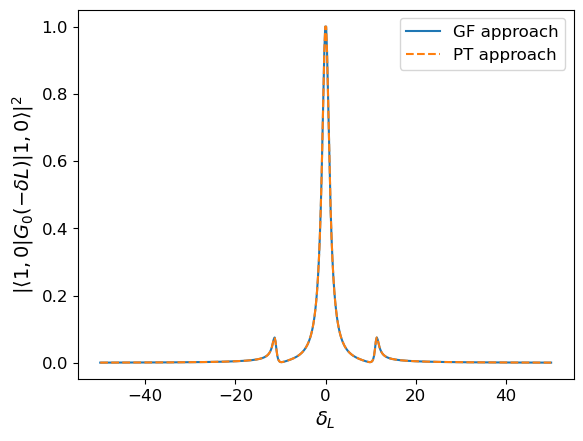

In [62]:
#plt.plot(δL, scal_prods.real)
#plt.plot(δL, scal_prods.imag)
#plt.plot(δL, np.abs(scal_prods) ** 2, label='10,00')
#plt.plot(δL, np.abs(scal_prods_2) ** 2, label='10,01')
plt.plot(δL, np.abs(scal_prods_3) ** 2 / (np.abs(scal_prods_3) ** 2).max(), label='GF approach')
plt.plot(δL, np.abs(pert_trans) ** 2 / (np.abs(pert_trans) ** 2).max(), '--', label='PT approach')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle 1,0|G_0(-δL)|1,0\\rangle|^2$")
plt.legend()
plt.savefig("scalar_products.png", format='png', dpi=300)

In [63]:
λ, ωc = sym.symbols("λ, ω_c")
Hc = sym.Matrix([[0, λ],
                 [λ, ωc]])
Hc

Matrix([
[0,   λ],
[λ, ω_c]])

In [64]:
Hc.eigenvects()

[(ω_c/2 - sqrt(4*λ**2 + ω_c**2)/2,
  1,
  [Matrix([
   [-ω_c/λ + (ω_c/2 - sqrt(4*λ**2 + ω_c**2)/2)/λ],
   [                                           1]])]),
 (ω_c/2 + sqrt(4*λ**2 + ω_c**2)/2,
  1,
  [Matrix([
   [-ω_c/λ + (ω_c/2 + sqrt(4*λ**2 + ω_c**2)/2)/λ],
   [                                           1]])])]

In [65]:
g10, g21, ω10, ω21 = sym.symbols("g_{10}, g_{21}, ω_{10}, ω_{21}")
Ha = sym.Matrix([[0, 0, 0],
                 [0, ω10, g21],
                [0, g21, ω21]])
Ha

Matrix([
[0,      0,      0],
[0, ω_{10}, g_{21}],
[0, g_{21}, ω_{21}]])

In [66]:
Ha.eigenvects()

[(0,
  1,
  [Matrix([
   [1],
   [0],
   [0]])]),
 (ω_{10}/2 + ω_{21}/2 - sqrt(4*g_{21}**2 + ω_{10}**2 - 2*ω_{10}*ω_{21} + ω_{21}**2)/2,
  1,
  [Matrix([
   [                                                                                                            0],
   [-ω_{21}/g_{21} + (ω_{10}/2 + ω_{21}/2 - sqrt(4*g_{21}**2 + ω_{10}**2 - 2*ω_{10}*ω_{21} + ω_{21}**2)/2)/g_{21}],
   [                                                                                                            1]])]),
 (ω_{10}/2 + ω_{21}/2 + sqrt(4*g_{21}**2 + ω_{10}**2 - 2*ω_{10}*ω_{21} + ω_{21}**2)/2,
  1,
  [Matrix([
   [                                                                                                            0],
   [-ω_{21}/g_{21} + (ω_{10}/2 + ω_{21}/2 + sqrt(4*g_{21}**2 + ω_{10}**2 - 2*ω_{10}*ω_{21} + ω_{21}**2)/2)/g_{21}],
   [                                                                                                            1]])])]

After thinking it over some more, I think that we really need to focus on determining which states are physically relevant for transmission.  My guess is that this should be $|0,0\rangle$ and $|1,0\rangle$.  Using these two seems to be the basis for the choice in the perturbation theory result of the Ningyuang paper.  Additionally, writing the perturbed eigenstate in terms of the eigenstates of $H_p$ makes it clear that we get three peaks from the fact that $H_p$ has only three eigenstates in the Ningyuang paper.  A full definition of $H$ for one atom has 6.  This might be muddying the waters by including non-relevant transitions in the spectrum.  As a first attempt, I'll try defining the Hamiltonian over only the states that we care about.

In [67]:
# Define the parameters for the Hamiltonian
g10 = 5
g21 = 10
Δ1 = 0.1
ω21 = 5
ωc = 5
κ = 1
γ21 = 1
γ10 = 0.05
λ = 1e-3

In [68]:
H = -1j*κ * qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[1], atom_bas[0]).dag()
H += -1j*γ10 * qu.tensor(cav_bas[0], atom_bas[1]) * qu.tensor(cav_bas[0], atom_bas[1]).dag()
H += -1j*γ21 * qu.tensor(cav_bas[0], atom_bas[2]) * qu.tensor(cav_bas[0], atom_bas[2]).dag()
H += g21 * (qu.tensor(cav_bas[0], atom_bas[2]) * qu.tensor(cav_bas[0], atom_bas[1]).dag() + qu.tensor(cav_bas[0], atom_bas[1]) * qu.tensor(cav_bas[0], atom_bas[2]).dag())
H += λ * (qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag() + qu.tensor(cav_bas[0], atom_bas[0]) * qu.tensor(cav_bas[1], atom_bas[0]).dag())
H

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00-0.05j 1.e+01+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   1.e+01+0.j   0.e+00-1.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00-1.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]]

In [69]:
# Create a list of basis vectors to shrink state space
H0_bas = [qu.tensor(cav_bas[0], atom_bas[i]) for i in range(3)]
H0_bas.append(qu.tensor(cav_bas[1], atom_bas[0]))

# Create empty matrix for storing values
H0_mat = np.zeros((len(H0_bas), len(H0_bas)), dtype=complex)
for i in range(len(H0_bas)):
    for j in range(len(H0_bas)):
        H0_mat[i][j] = H0_bas[i].dag() * H * H0_bas[j]

H0 = qu.Qobj(H0_mat)
H0

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j  ]
 [0.e+00+0.j   0.e+00-0.05j 1.e+01+0.j   0.e+00+0.j  ]
 [0.e+00+0.j   1.e+01+0.j   0.e+00-1.j   0.e+00+0.j  ]
 [1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00-1.j  ]]

In [70]:
V_mat = np.zeros_like(H0_mat)
V_mat[3][1] = g10
V_mat[1][3] = g10
V = qu.Qobj(V_mat)
V

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 5.]
 [0. 0. 0. 0.]
 [0. 5. 0. 0.]]

In [71]:
Gs = np.zeros(δL.shape[0], dtype=object)
eig_vals = np.zeros((δL.shape[0], 4), dtype=complex)
eig_states = np.zeros(δL.shape[0], dtype=object)
for i in range(δL.shape[0]):
    temp = np.zeros_like(H0_mat)
    temp[0][0] = -δL[i]
    temp = qu.Qobj(temp)
    x = (temp + H0 + V).eigenstates()
    eig_vals[i] = x[0]
    eig_states[i] = x[1]

    Gs[i] = exact_resolvent(δL[i], temp + H0 + V)

In [72]:
a = np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,3)) ** 2 for _ in Gs])
b = np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,2)) ** 2 for _ in Gs])
c = np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,1)) ** 2 for _ in Gs])
d = np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,0)) ** 2 for _ in Gs])

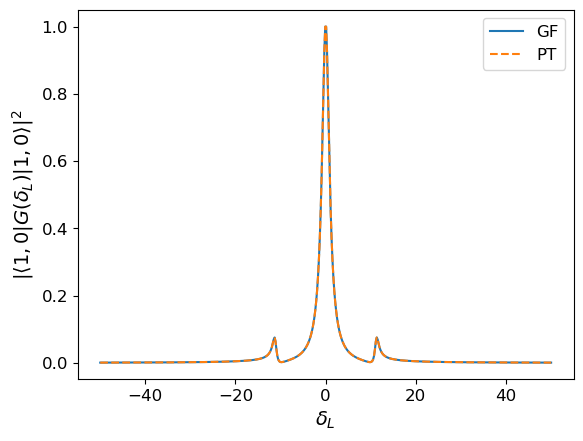

In [73]:
plt.plot(δL, a / a.max(), label='GF')
plt.plot(δL, np.abs(pert_trans) ** 2 / (np.abs(np.abs(pert_trans) ** 2)).max(), '--', label='PT')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle1,0|G(\\delta_L)|1,0\\rangle|^2$")
plt.legend()
plt.savefig("2nd_gf_pt_comp.png", format='png', dpi=300)
#plt.plot(δL, b)
#plt.plot(δL, c)
#plt.plot(δL, d)

Text(0.5, 1.0, 'Imaginary')

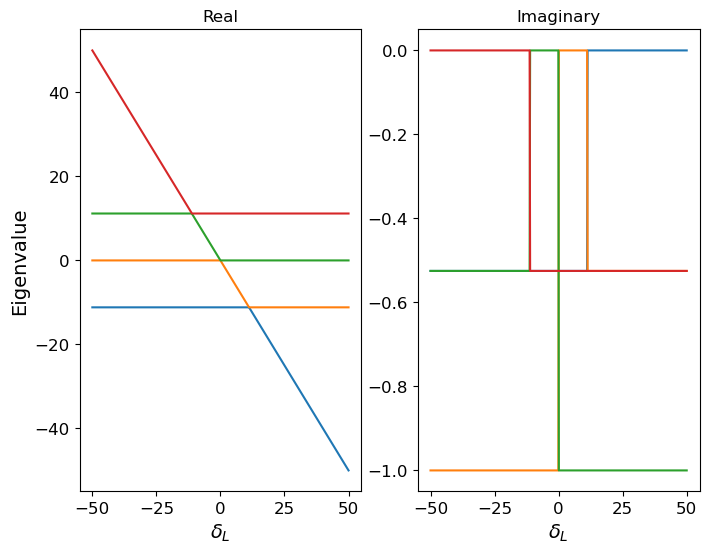

In [74]:
fig = plt.figure(1, figsize=(8,6))
ax = fig.subplots(1,2)
for i in range(4):
    ax[0].plot(δL, eig_vals.T[i].real)
    ax[1].plot(δL, eig_vals.T[i].imag)
ax[0].set_xlabel("$\\delta_L$")
ax[0].set_ylabel("Eigenvalue")
ax[0].set_title("Real")
ax[1].set_xlabel("$\\delta_L$")
ax[1].set_title("Imaginary")

In [75]:
resolvent_of_eigvals = np.zeros((δL.shape[0], 4), dtype=complex)
for i in range(δL.shape[0]):
    for j in range(4):
        resolvent_of_eigvals[i][j] = 1/(δL[i] - eig_vals[i][j])

Text(0.5, 1.0, 'Imaginary')

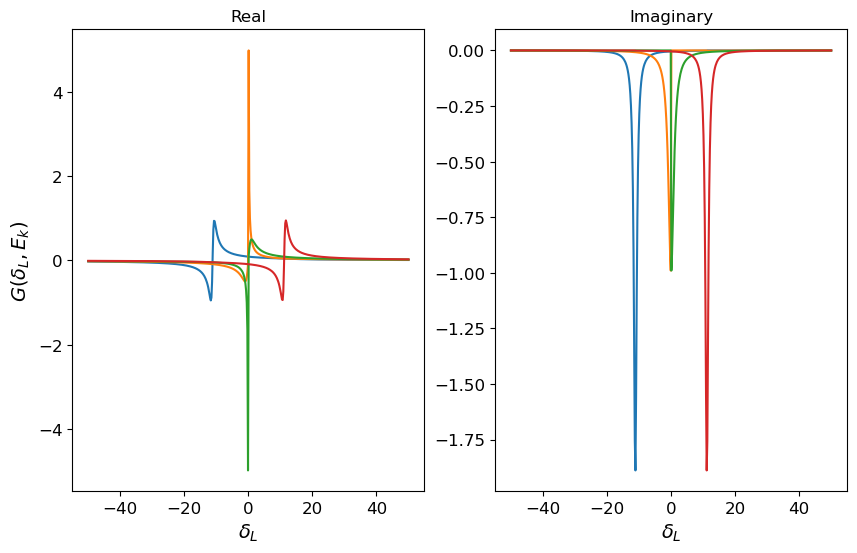

In [76]:
fig = plt.figure(1, figsize=(10,6))
ax = fig.subplots(1,2)
for i in range(4):
    ax[0].plot(δL, resolvent_of_eigvals.T[i].real)
    ax[1].plot(δL, resolvent_of_eigvals.T[i].imag)


ax[0].set_xlabel("$\\delta_L$")
ax[0].set_ylabel("$G(\\delta_L, E_k)$")
ax[0].set_title("Real")
ax[1].set_xlabel("$\\delta_L$")
ax[1].set_title("Imaginary")

So this seems to be working.  We can get the same results as the perturbation theory, but I didn't have to invoke the perturbed eigenstate in order to do this.  As another check, we should be able to change the detuning of the transition from the cavity mode (i.e. $\Delta_1$ here) and see that the transmission returns to being that of the bare cavity.  Let's try that.  Note that in the Ningyuang paper, they have a detuning term on $|1,0\rangle$ ($\delta_c$) and $|0,2\rangle$ ($\delta_R$).  The former is what we call $\Delta_1$ and the latter is what we call $\delta_c$.

In [77]:
# Define the Δ1 values we want to check - we'll keep the other detuning on 0 for now
Δ1s = np.array([0, 15, 30])

In [78]:
# Define the Hamiltonians associated with these detunings - this can be done by adding a new term to our old Hamiltonian
Hs = [_ * qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[1], atom_bas[0]).dag() + H for _ in Δ1s]
Hs[2]

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00-0.05j 1.e+01+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   1.e+01+0.j   0.e+00-1.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   3.e+01-1.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j  ]]

In [79]:
# Now filter out the states we don't care about
# Create a list of basis vectors to shrink state space
H0_bas = [qu.tensor(cav_bas[0], atom_bas[i]) for i in range(3)]
H0_bas.append(qu.tensor(cav_bas[1], atom_bas[0]))

# Create empty matrix for storing values
H0_mats = np.zeros((Δ1s.shape[0], len(H0_bas), len(H0_bas)), dtype=complex)
for k in range(Δ1s.shape[0]):
    for i in range(len(H0_bas)):
        for j in range(len(H0_bas)):
            H0_mats[k][i][j] = H0_bas[i].dag() * Hs[k] * H0_bas[j]

H0s = [qu.Qobj(_) for _ in H0_mats]
H0s[2]

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j  ]
 [0.e+00+0.j   0.e+00-0.05j 1.e+01+0.j   0.e+00+0.j  ]
 [0.e+00+0.j   1.e+01+0.j   0.e+00-1.j   0.e+00+0.j  ]
 [1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   3.e+01-1.j  ]]

In [80]:
# Now we can calculate the exact resolvent for each value of δL for each of these Hamiltonians
Gs = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)
eig_vals = np.zeros((Δ1s.shape[0], δL.shape[0], 4), dtype=complex)
eig_states = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)
for k in range(Δ1s.shape[0]):
    for i in range(δL.shape[0]):
        temp = np.zeros_like(H0_mat)
        temp[0][0] = -δL[i]
        temp = qu.Qobj(temp)
        x = (temp + H0s[k] + V).eigenstates()
        eig_vals[k][i] = x[0]
        eig_states[k][i] = x[1]

        Gs[k][i] = exact_resolvent(δL[i], temp + H0s[k] + V)

In [81]:
transmission = [np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,3)) ** 2 for _ in Gs[k]]) for k in range(Δ1s.shape[0])]

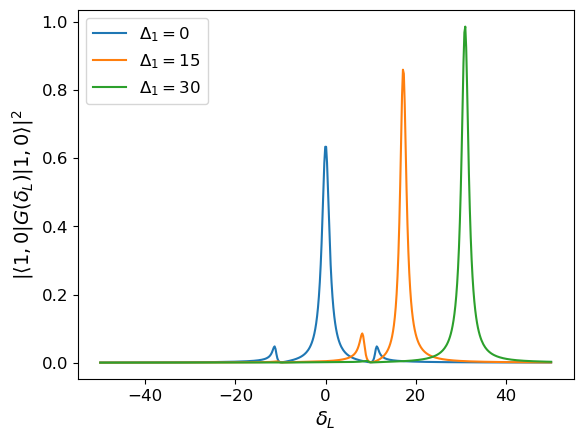

In [82]:
for i in range(Δ1s.shape[0]):
    plt.plot(δL, transmission[i], label='$\\Delta_1=' + str(Δ1s[i]) + '$')
#plt.plot(δL, np.abs(pert_trans) ** 2 / (np.abs(np.abs(pert_trans) ** 2)).max(), '--', label='PT')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle1,0|G(\\delta_L)|1,0\\rangle|^2$")
plt.legend()

So this looks more or less like what we expect in that increasing $\Delta_1$ too much means you just get the bare cavity response back.  I would have expected the peak to remain centered on 0.  I think that this shift is essentially due to the way that the detuning is defined in the Ningyuang paper.

The next step is to check how the accurate our results are when we use the approximate sum (Eq. A.24 in Ch. 3 of CT) instead of the exact expression for the resolvent that we used above.  For now, it should suffice to calculate the exact resolvent of $H_0$.  The formula in Eq. A.25 is for getting a particular matrix element in the eigenstate basis of $H_0$ and should therefore give essentially the same result with the appropriate transformations to the cavity-atom excitation basis.

In [83]:
# Calculate the values of G0 that we'll be using
G0s = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)
H0_eig_vals = np.zeros((Δ1s.shape[0], δL.shape[0], 4), dtype=complex)
H0_eig_states = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)

for k in range(Δ1s.shape[0]):
    for i in range(δL.shape[0]):
        temp = np.zeros_like(H0_mat)
        temp[0][0] = -δL[i]
        temp = qu.Qobj(temp)
        x = (temp + H0s[k] + V).eigenstates()
        H0_eig_vals[k][i] = x[0]
        H0_eig_states[k][i] = x[1]

        G0s[k][i] = exact_resolvent(δL[i], temp + H0s[k])

In [84]:
# Now calculate Gs using Eq. A.24
app_Gs = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)
for k in range(Δ1s.shape[0]):
    for i in range(δL.shape[0]):
        app_Gs[k][i] = (G0s[k][i] + G0s[k][i] * V * G0s[k][i] + G0s[k][i] * V * G0s[k][i] * V * G0s[k][i]
                        + G0s[k][i] * V * G0s[k][i] * V * G0s[k][i] * V * G0s[k][i]
                        + G0s[k][i] * V * G0s[k][i] * V * G0s[k][i] * V * G0s[k][i] * V * G0s[k][i])

In [85]:
# Calculate the transmission spectra using this approximate form
approx_trans = [np.array([np.abs(qu.basis(4,3).dag() * _ * qu.basis(4,3)) ** 2 for _ in app_Gs[k]]) for k in range(Δ1s.shape[0])]

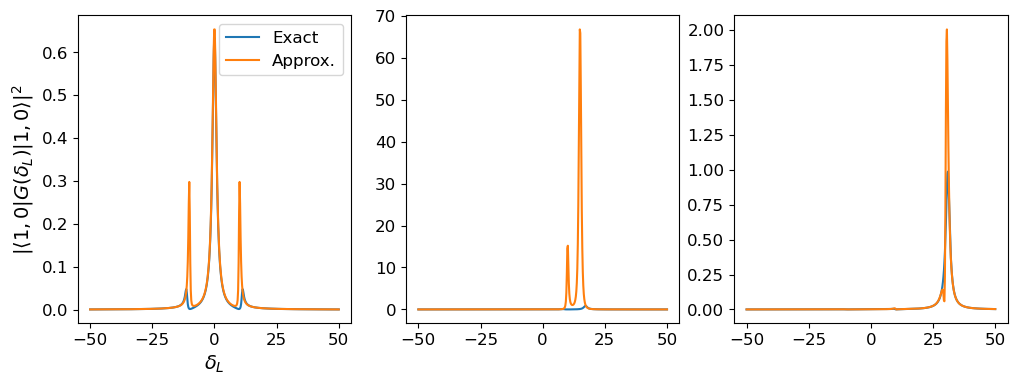

In [86]:
fig = plt.figure(1, figsize=(12, 4))
ax = fig.subplots(1,3)
for i in range(Δ1s.shape[0]):
    ax[i].plot(δL, transmission[i], label='Exact')
    ax[i].plot(δL, approx_trans[i], label='Approx.')
#plt.plot(δL, np.abs(pert_trans) ** 2 / (np.abs(np.abs(pert_trans) ** 2)).max(), '--', label='PT')
ax[0].set_xlabel("$\\delta_L$")
ax[0].set_ylabel("$|\\langle1,0|G(\\delta_L)|1,0\\rangle|^2$")
ax[0].legend()

So it doesn't look like the approximation is too accurate.  Playing around with the values of $g_{10}$ and $g_{21}$, I have found that decreasing $g_{21}$ does make the results more accurate to a point.  The problem is that in this setup, we really need $g_{21} > g_{10}$ to get decent results.  If that's not true, it doesn't seem like decreasing $g_{21}$ really does anything to improve the accuracy.

One thing that we can do to get a better handle on this is to calculate the norm difference between $G(z_0)$ and $G_0(z_0)$ as we increase the number of terms in the sum.  If the error decreases with more terms, we know that truncating it at some point should be perfectly valid.  If it grows, then the truncation is probably not really valid ever for this system.  Adding more atoms to the system may improve this feature because the coupling terms are per atom and so should both become smaller.

In [90]:
err = [(Gs[0][0] - G0s[0][0]).norm()]
temp = G0s[0][0]
for i in range(20):
    temp2 = temp * V * G0s[0][0]
    temp += temp2
    err.append((Gs[0][0] - temp).norm())


([<matplotlib.axis.XTick at 0x7e4c7ef5fb10>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20')])

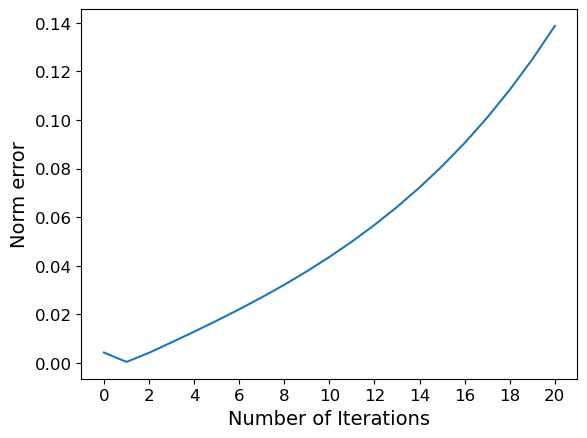

In [96]:
plt.plot(np.arange(21), err)
plt.xlabel("Number of Iterations")
plt.ylabel("Norm error")
plt.xticks([2*i for i in range(11)])